In [1]:
setwd("./data/metabolomics")

# Load and pre-process data

Data is loaded into a list with 3 items:
* expr_matrix: matrix (double) f × n - Raw values for each feature (f) in each sample (n)
* sample_metadata: data.frame n × ? - Metadata associated with each sample (n)
* feature_metadata: data.frame f × ? - Metadata associated with each feature (f)

In [2]:
load_data_matrices <- function(expr_data_path, 
                               sample_data_path,
                               feature_data_path
                               ) {
  
  expr_matrix <- as.matrix(read.csv(expr_data_path, row.names="X", sep="\t"))
  sample_meta <- read.csv(sample_data_path, row.names="X", sep="\t")
  feature_meta <- read.csv(feature_data_path, row.names="X", sep="\t")
    
  return(list(
    expr_matrix = expr_matrix,
    sample_metadata = sample_meta,
    feature_metadata = feature_meta
  ))
}

In [3]:
targeted_data <- load_data_matrices(
  expr_data_path="2026-04-01_targeted_expr_matrix.tsv",
  sample_data_path="2026-04-01_targeted_sample_metadata.tsv",
  feature_data_path="2026-04-01_targeted_feature_metadata.tsv"
)

untargeted_data <- load_data_matrices(
 expr_data_path="2026-04-01_untargeted_expr_matrix.tsv",
 sample_data_path="2026-04-01_untargeted_sample_metadata.tsv",
 feature_data_path="2026-04-01_untargeted_feature_metadata.tsv"
)

In [5]:
# Replicate the name sanitation in my sample tables
targeted_data$sample_metadata$sample <- make.names(targeted_data$sample_metadata$sample)
targeted_data$sample_metadata$sample_treatment <- make.names(targeted_data$sample_metadata$sample_treatment)
untargeted_data$sample_metadata$sample <- make.names(untargeted_data$sample_metadata$sample)
untargeted_data$sample_metadata$sample_treatment <- make.names(untargeted_data$sample_metadata$sample_treatment)

# The targeted data includes information on other variables,
#   such as retention time and peak area.
# Filter it to only include peak height
targeted_data$expr_matrix <- targeted_data$expr_matrix[
  targeted_data$feature_metadata["variable"] == "peak_height", ]
targeted_data$feature_metadata <- targeted_data$feature_metadata[
  targeted_data$feature_metadata["variable"] == "peak_height", ]

# Replace 0's with NaN in both targeted and untargeted data
targeted_data$expr_matrix[targeted_data$expr_matrix == 0] <- NaN
untargeted_data$expr_matrix[untargeted_data$expr_matrix == 0] <- NaN

### Supplemental figure S7

Histogram of peak heights across all metabolomics samples

Warning message:
“Removed 27447 rows containing non-finite outside the scale range
(`stat_bin()`).”
Warning message:
“Removed 1889211 rows containing non-finite outside the scale range
(`stat_bin()`).”
Warning message:
“Removed 27447 rows containing non-finite outside the scale range
(`stat_bin()`).”
Warning message:
“Removed 1889211 rows containing non-finite outside the scale range
(`stat_bin()`).”


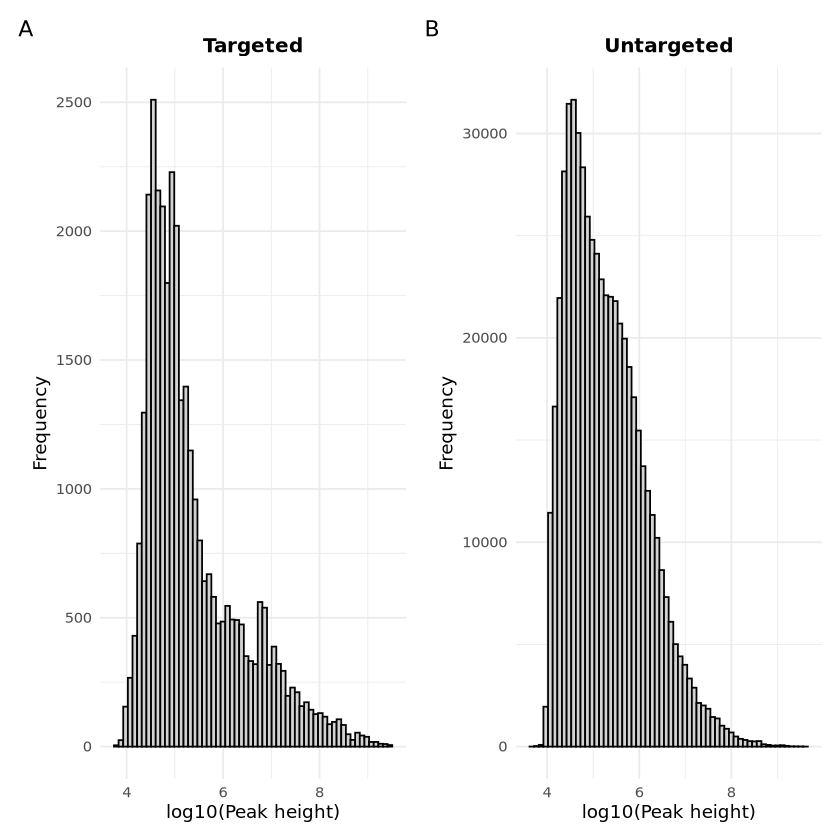

In [6]:
library(ggplot2)
library(patchwork)

# Create data frames for ggplot
targeted_df <- data.frame(value = log10(as.vector(targeted_data$expr_matrix)))
untargeted_df <- data.frame(value = log10(as.vector(untargeted_data$expr_matrix)))

# Create the plots
plot_targeted <- ggplot(targeted_df, aes(x = value)) +
  geom_histogram(bins = 60, fill="lightgrey", color="black") +
  labs(title = "Targeted",
       x = "log10(Peak height)",
       y = "Frequency") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 12, face = "bold"))

plot_untargeted <- ggplot(untargeted_df, aes(x = value)) +
  geom_histogram(bins = 60, fill="lightgrey", color="black") +
  labs(title = "Untargeted",
       x = "log10(Peak height)",
       y = "Frequency") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 12, face = "bold"))

combined_plot <- (plot_targeted | plot_untargeted) +
  plot_annotation(tag_levels = 'A')

ggsave("2026-04-05_pfu_histograms.png", combined_plot,
       dpi = 300, width = 10, height = 5)

combined_plot

Calculating missing data proportions for the manuscript

In [7]:
samples <- make.names(c('Abes-MACB1034-100A', 'Abes-RKCB94-100A', 'Pfu-COM1', 'Pfu-MW698-BDO'))

isnan_arr <- is.na(as.vector(targeted_data$expr_matrix[
  , targeted_data$sample_metadata$sample_treatment %in% samples]))
cat(paste("Proportion of missing data in targeted data:",
  round(sum(isnan_arr) / length(isnan_arr), 3), "\n"))

isnan_arr <- is.na(as.vector(untargeted_data$expr_matrix[
  , untargeted_data$sample_metadata$sample_treatment %in% samples]))
cat(paste("Proportion of missing data in untargeted data:",
  round(sum(isnan_arr) / length(isnan_arr), 3), "\n"))

Proportion of missing data in targeted data: 0.094 
Proportion of missing data in untargeted data: 0.472 


# Missing data filtering and imputation

There is a small amount of missing data in the targeted data (9.4%) and a large amount missing in the untargeted data (47.2%). This is common in mass spec experiments, and many methods for imputing missing data exist so that we can still compute differential abundance statistics for peaks with missing data. 

Methods are broken up depending on the type of missingness expected in the data. 
If we expect that data is missing due to pure randomness (MAR/MCAR; Missing \[Completely\] At Random), methods can be used to replace missing data with values that have similar properies to the existing data (e.g. mean intensity, drawing from a gaussian distribution fit to the data, random forest approaches). 

Otherwise the data is considered Missing Not at Random (MNAR). This can happen in mass spec when intensities fall below some detection limit. In this case, you need to make some assumptions to allow you to impute values that are lower than your existing data. Two methods are typically used for this: replace with half the minimum value, or quantile regression imputation of left-censored data (QRILC). 

Often the recommendation is simply to test different methods on your dataset and evaluate how they perform. For more discussion, see:
* Wei et al. 2018. Missing Value Imputation Approach for Mass Spectrometry-based 
Metabolomics Data. https://doi.org/10.1038/s41598-017-19120-0
* Shi et al. 2025. Optimizing imputation strategies for mass spectrometry-based proteomics considering intensity and missing value rates. https://doi-org.uri.idm.oclc.org/10.1016/j.csbj.2025.04.041
* Chilimoniuk et al. 2024. imputomics: web server and R package for missing values imputation in metabolomics data. https://doi-org.uri.idm.oclc.org/10.1093/bioinformatics/btae098

In our case, based on the truncated untargeted peak height distribution (above), I hypothesized that our data is mostly MNAR with a detection limit of ~1e-4. I also predict that our data has less random missingness than many older metabolomics/proteomics experiments because JGI used Data-Independent Acquisition (DIA) methods as opposed to Data-Dependent Acquisition (DDA). DDA involves isolating specific MS1 peaks for fragmentation based on a selection criterion (e.g. top 50 highest intensity peaks), resulting in a subset of the data being dropped. DIA methods scan the entire spectrum and should have less random missing data problems. For these reasons I used QRILC below.

I filtered features missing from > 80% of samples (per-organism) and imputed the rest with QRILC under a MNAR assumption.

In [15]:
options(repr.plot.width = 12, repr.plot.height = 12)

In [8]:
library(imputeLCMD)
library(ggplot2)
library(patchwork)

run_imputation_pipeline <- function(data_obj,
                                    samples_of_interest,
                                    dataset_name,
                                    filter_threshold = 0.8) {
  
  # Subset to samples of interest
  sample_subset <- data_obj$sample_metadata$sample_treatment %in% samples_of_interest
  expr_subset <- data_obj$expr_matrix[, sample_subset]
  
  # Calculate missingness
  missing_prop <- apply(expr_subset, 1, function(x) sum(is.na(x)) / length(x))
  
  # Filter features
  keep_features <- missing_prop < filter_threshold
  expr_filtered <- expr_subset[keep_features, ]
  
  if (nrow(expr_filtered) == 0) {
    stop("No features remaining after filtering. Try increasing filter_threshold.")
  }
  
  # Log transform if needed
  range_filtered <- range(expr_filtered, na.rm = TRUE)
  needs_log <- range_filtered[2] > 100
  expr_for_impute <- if (needs_log) log2(expr_filtered) else expr_filtered
  
  # QRILC imputation
  impute_results <- imputeLCMD::impute.QRILC(t(expr_for_impute))
  expr_imputed <- t(impute_results[[1]])
  
  # Prepare data for plots
  was_missing <- is.na(expr_for_impute)
  imputed_values <- expr_imputed[was_missing]
  observed_values <- as.vector(expr_for_impute[!was_missing])
  missing_per_sample <- apply(expr_for_impute, 2, function(x) sum(is.na(x)) / length(x))
  
  # ===== PLOT PANELS =====
  
  # Plot 1: Missing data proportions histogram
  p1 <- ggplot(data.frame(prop = missing_prop), aes(x = prop)) +
    geom_histogram(bins = 20, fill = "lightblue", color = "darkblue", boundary=-1) +
    geom_vline(xintercept = filter_threshold, color = "red", linetype = "dashed", linewidth = 1) +
    annotate("text", x = filter_threshold, y = Inf, label = paste("Threshold =", filter_threshold),
             hjust = 1.1, vjust = 2, color = "red") +
    labs(title = "Missing Data Proportions per Feature", x = "Proportion Missing", y = "Number of Features") +
    xlim(0, 1) +
    theme_bw()
  
  # Plot 2: Before vs After imputation
  before_df <- data.frame(value = as.vector(expr_for_impute), type = "Before")
  after_df <- data.frame(value = as.vector(expr_imputed), type = "After")
  combined_df <- na.omit(rbind(before_df, after_df))
  
  p2 <- ggplot(combined_df, aes(x = value, fill = type)) +
    geom_histogram(bins = 40, alpha = 0.5, position = "identity") +
    scale_fill_manual(values = c("Before" = "red", "After" = "blue")) +
    labs(title = "Before vs After Imputation", x = "Log2 Intensity", y = "Frequency", fill = "") +
    theme_bw() +
    theme(legend.position = "top")
  
  # Plot 3: Imputed vs Observed density
  density_df <- rbind(
    data.frame(value = observed_values, type = paste0("Observed (n=", format(length(observed_values), big.mark = ","), ")")),
    data.frame(value = imputed_values, type = paste0("Imputed (n=", format(length(imputed_values), big.mark = ","), ")"))
  )
  
  p3 <- ggplot(density_df, aes(x = value, color = type, linetype = type)) +
    geom_density(linewidth = 1) +
    scale_color_manual(values = c("darkgreen", "darkorange")) +
    scale_linetype_manual(values = c("solid", "dashed")) +
    labs(title = "Imputed vs Observed Values", x = "Log2 Intensity", y = "Density", color = "", linetype = "") +
    theme_bw() +
    theme(legend.position = "top")
  
  # Plot 4: Per-sample missingness
  sample_df <- data.frame(
    sample = factor(names(missing_per_sample), levels = names(missing_per_sample)),
    prop = missing_per_sample
  )
  mean_missing <- mean(missing_per_sample)
  
  p4 <- ggplot(sample_df, aes(x = sample, y = prop)) +
    geom_col(fill = "steelblue") +
    geom_hline(yintercept = mean_missing, color = "red", linetype = "dashed", linewidth = 1) +
    annotate("text", x = 1, y = mean_missing, label = paste("Mean =", round(mean_missing, 3)),
             vjust = -0.5, hjust = 0, color = "red") +
    labs(title = "Missing Data per Sample", x = "", y = "Proportion Missing") +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
  
  # Combine plots
  combined <- (p1 | p2) / (p3 | p4) +
    plot_annotation(title = paste(dataset_name, "- Imputation Diagnostics"))
  
  return(list(
    expr_matrix = expr_imputed,
    feature_metadata = data_obj$feature_metadata[keep_features, ],
    sample_metadata = data_obj$sample_metadata[sample_subset, ],
    plot = combined
  ))
}

Loading required package: tmvtnorm

Loading required package: mvtnorm

Loading required package: Matrix

Loading required package: stats4

Loading required package: gmm

Loading required package: sandwich

Loading required package: norm

This package has some major limitations
(for example, it does not work reliably when
the number of variables exceeds 30),
and has been superseded by the norm2 package.

Loading required package: pcaMethods

Loading required package: Biobase

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:sandwich’:

    estfun


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplic

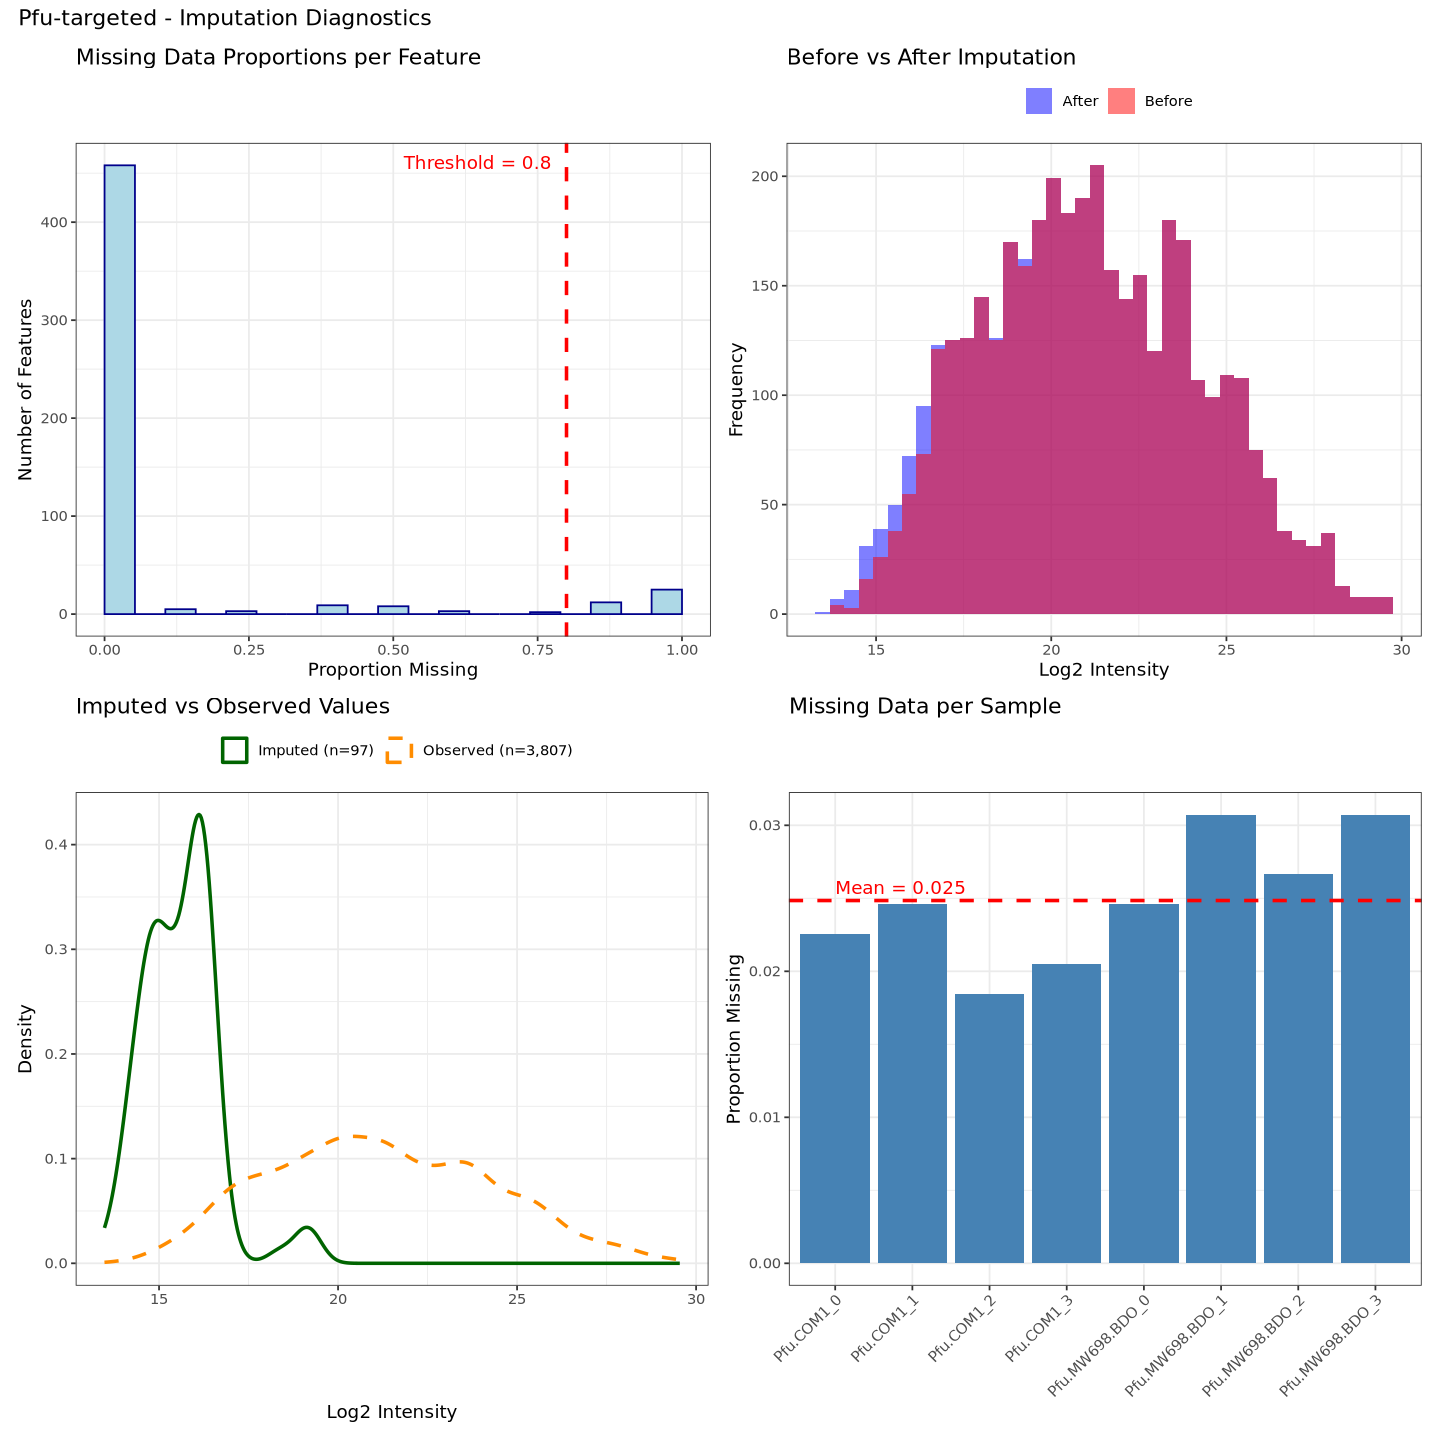

In [16]:
pfu_targeted_imputed <- run_imputation_pipeline(
  targeted_data,
  samples_of_interest = make.names(c('Pfu-COM1', 'Pfu-MW698-BDO')),
  dataset_name = "Pfu-targeted",
  filter_threshold = 0.8
)

pfu_targeted_imputed$plot

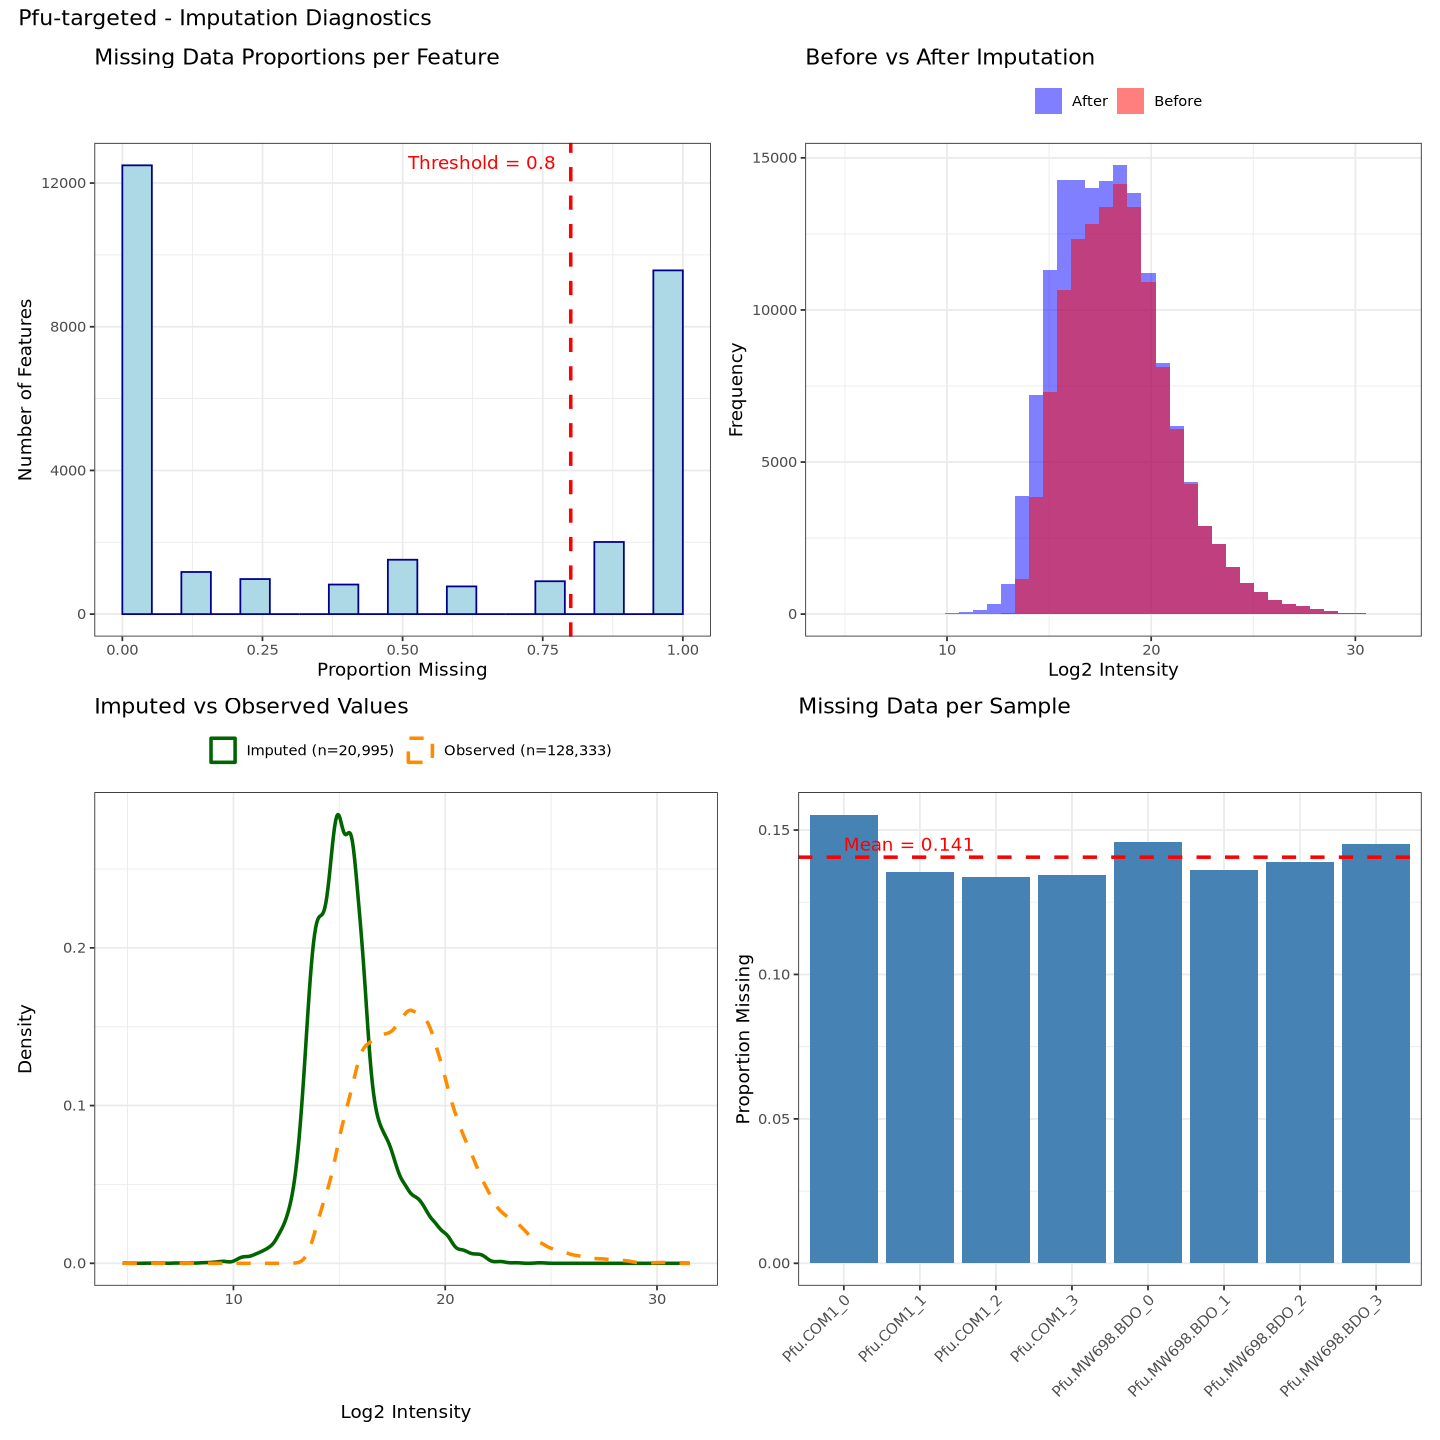

In [17]:
pfu_untargeted_imputed <- run_imputation_pipeline(
  untargeted_data,
  samples_of_interest = make.names(c('Pfu-COM1', 'Pfu-MW698-BDO')),
  dataset_name = "Pfu-targeted",
  filter_threshold = 0.8
)

pfu_untargeted_imputed$plot

In [ ]:
Save data to make plots in python:

# Export expression matrix
write.csv(data_list$expr_matrix, "expr_matrix.csv", row.names = TRUE)

# Export feature metadata
write.csv(data_list$feature_metadata, "feature_metadata.csv", row.names = TRUE)

# Limma

LIMMA was first developed for differential expression analysis of microarray data but can be used here as well. With LIMMA we develop a linear model for each feature (i.e. peak) across our samples, and it uses some bayesian magic to help share information across features so that we can better estimate parameters like the peak height variance, which can be difficult to accurately estimate otherwise due to our small sample sizes (3 for Abes and 4 for Pfu). See their publication for more: https://doi.org/10.1093/nar/gkv007

This approach appears to give similar results to our previous method (a bunch of t-tests), which is good, and it's much faster to compute and will be easier to extend to more complex sample designs in the future.

In [12]:
library(limma)
library(ggplot2)
library(patchwork)
library(reshape2)

run_limma_analysis <- function(data_obj, dataset_name, 
                                group_column = "sample_treatment",
                                contrast = NULL,  # e.g., "Treatment - Control"
                                sample_id_column = "sample",
                                feature_name_column = "metabolite") {
  
  expr_matrix <- data_obj$expr_matrix
  sample_metadata <- data_obj$sample_metadata
  feature_metadata <- data_obj$feature_metadata
  
  if (sample_id_column %in% colnames(sample_metadata)) {
    rownames(sample_metadata) <- sample_metadata[[sample_id_column]]
  }
  
  stopifnot(group_column %in% colnames(sample_metadata))
  
  samples_in_expr <- colnames(expr_matrix)
  sample_metadata <- sample_metadata[samples_in_expr, , drop = FALSE]
  sample_groups <- factor(sample_metadata[[group_column]])
  
  stopifnot(nlevels(sample_groups) >= 2)
  
  # Design matrix
  design <- model.matrix(~0 + sample_groups)
  colnames(design) <- levels(sample_groups)
  
  # Handle contrast specification
  available_groups <- levels(sample_groups)
  
  if (is.null(contrast)) {
    stop("Please specify a contrast, e.g., contrast = 'Treatment - Control'\n",
         "Available groups: ", paste(available_groups, collapse = ", "))
  }
  
  # Parse contrast to validate group names
  contrast_terms <- trimws(unlist(strsplit(contrast, "[-+]")))
  contrast_terms <- contrast_terms[contrast_terms != ""]
  
 invalid_terms <- contrast_terms[!contrast_terms %in% available_groups]
  if (length(invalid_terms) > 0) {
    stop("Invalid group name(s) in contrast: ", paste(invalid_terms, collapse = ", "), "\n",
         "Available groups: ", paste(available_groups, collapse = ", "))
  }
  
  # Create contrast matrix
  contrast_matrix <- makeContrasts(contrasts = contrast, levels = design)
  contrast_name <- gsub(" ", "", contrast)  # Clean name for filenames
  colnames(contrast_matrix) <- contrast_name
  
  # Fit model
 expr_norm <- expr_matrix
  fit <- lmFit(expr_norm, design)
  fit2 <- contrasts.fit(fit, contrast_matrix)
  fit2 <- eBayes(fit2)
  
  results <- topTable(fit2, number = Inf, adjust.method = "BH", sort.by = "P")
  results$feature_id <- rownames(results)
  
  if (!is.null(feature_metadata)) {
    feature_metadata$feature_id <- rownames(feature_metadata)
    results <- merge(results, feature_metadata, by = "feature_id", all.x = TRUE)
  }
  
  results$significance <- ifelse(results$adj.P.Val >= 0.05, "NS",
                           ifelse(results$logFC > 0, "Up", "Down"))
  
  # ===== PLOT PANELS =====
  
  p1 <- ggplot(results, aes(x = P.Value)) +
    geom_histogram(bins = 50, fill = "lightblue", color = "black") +
    labs(title = "P-value Distribution", x = "Raw P-value", y = "Count") +
    theme_bw()
  
  p2 <- ggplot(results, aes(x = logFC, y = -log10(adj.P.Val), color = significance)) +
    geom_point(alpha = 0.7) +
    scale_color_manual(values = c("Down" = "blue", "NS" = "gray", "Up" = "red")) +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed") +
    geom_vline(xintercept = c(-1, 1), linetype = "dashed") +
    labs(title = "Volcano Plot", subtitle = contrast,
         x = "Log2 Fold Change", y = "-log10(adj. p-value)") +
    theme_bw()
  
  p3 <- ggplot(results, aes(x = AveExpr, y = logFC, color = adj.P.Val < 0.05)) +
    geom_point(alpha = 0.7) +
    scale_color_manual(values = c("TRUE" = "red", "FALSE" = "gray"), 
                       labels = c("NS", "FDR < 0.05")) +
    geom_hline(yintercept = c(-1, 0, 1), linetype = c("dashed", "solid", "dashed")) +
    labs(title = "MA Plot", x = "Average Log2 Expression", y = "Log2 Fold Change", color = "") +
    theme_bw()
  
  pca <- prcomp(t(expr_norm), scale = FALSE)
  var_explained <- round(100 * summary(pca)$importance[2, 1:2], 1)
  pca_df <- data.frame(
    PC1 = pca$x[, 1], PC2 = pca$x[, 2],
    Group = sample_groups, Sample = colnames(expr_norm)
  )
  
  p4 <- ggplot(pca_df, aes(x = PC1, y = PC2, color = Group, label = Sample)) +
    geom_point(size = 3) +
    geom_text(vjust = -1, size = 2.5) +
    labs(title = "PCA", 
         x = paste0("PC1 (", var_explained[1], "%)"),
         y = paste0("PC2 (", var_explained[2], "%)")) +
    theme_bw()
  
  mv_df <- data.frame(AveExpr = fit2$Amean, sigma = sqrt(fit2$s2.post))
  p5 <- ggplot(mv_df, aes(x = AveExpr, y = sigma)) +
    geom_point(alpha = 0.5) +
    geom_smooth(color = "red", se = FALSE) +
    labs(title = "Mean-Variance Trend", x = "Average Log2 Expression", y = "Sqrt(Posterior Variance)") +
    theme_bw()
  
  # Heatmap
  n_sig <- sum(results$adj.P.Val < 0.05)
  if (n_sig > 0) {
    n_top <- min(50, n_sig)
    top_features <- head(results[order(results$adj.P.Val), "feature_id"], n_top)
    heatmap_data <- t(scale(t(expr_norm[top_features, , drop = FALSE])))
    
    if (feature_name_column %in% colnames(results)) {
      display_labels <- results[[feature_name_column]][match(top_features, results$feature_id)]
    } else {
      display_labels <- top_features
    }
    
    row_order <- hclust(dist(heatmap_data))$order
    col_order <- hclust(dist(t(heatmap_data)))$order
    
    hm_long <- expand.grid(RowIdx = seq_len(nrow(heatmap_data)), ColIdx = seq_len(ncol(heatmap_data)))
    hm_long$Value <- as.vector(heatmap_data)
    hm_long$FeatureLabel <- display_labels[hm_long$RowIdx]
    hm_long$Sample <- colnames(heatmap_data)[hm_long$ColIdx]
    hm_long$RowPos <- match(hm_long$RowIdx, row_order)
    hm_long$ColPos <- match(hm_long$ColIdx, col_order)
    
    ordered_labels <- display_labels[row_order]
    ordered_samples <- colnames(heatmap_data)[col_order]
    
    p6 <- ggplot(hm_long, aes(x = ColPos, y = RowPos, fill = Value)) +
      geom_tile() +
      scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
      scale_y_continuous(breaks = seq_along(ordered_labels), labels = ordered_labels, expand = c(0, 0)) +
      scale_x_continuous(breaks = seq_along(ordered_samples), labels = ordered_samples, expand = c(0, 0)) +
      labs(title = paste("Top", n_top, "Features"), x = "Sample", y = "Feature", fill = "Z-score") +
      theme_bw() +
      theme(axis.text.x = element_text(angle = 45, hjust = 1),
            axis.text.y = element_text(size = ifelse(n_top > 30, 5, 7)))
  } else {
    p6 <- ggplot() + 
      annotate("text", x = 0.5, y = 0.5, label = "No significant features\n(FDR < 0.05)") +
      theme_void()
  }
  
  combined <- (p1 | p2) / (p3 | p4) / (p5 | p6) +
    plot_annotation(title = dataset_name, subtitle = paste("Contrast:", contrast))
  
  return(list(
    fit = fit2,
    results = results,
    expr_norm = expr_norm,
    sample_groups = sample_groups,
    sample_metadata = sample_metadata,
    feature_metadata = feature_metadata,
    contrast = contrast,
    plot = combined
  ))
}


Attaching package: ‘limma’


The following object is masked from ‘package:BiocGenerics’:

    plotMA




`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


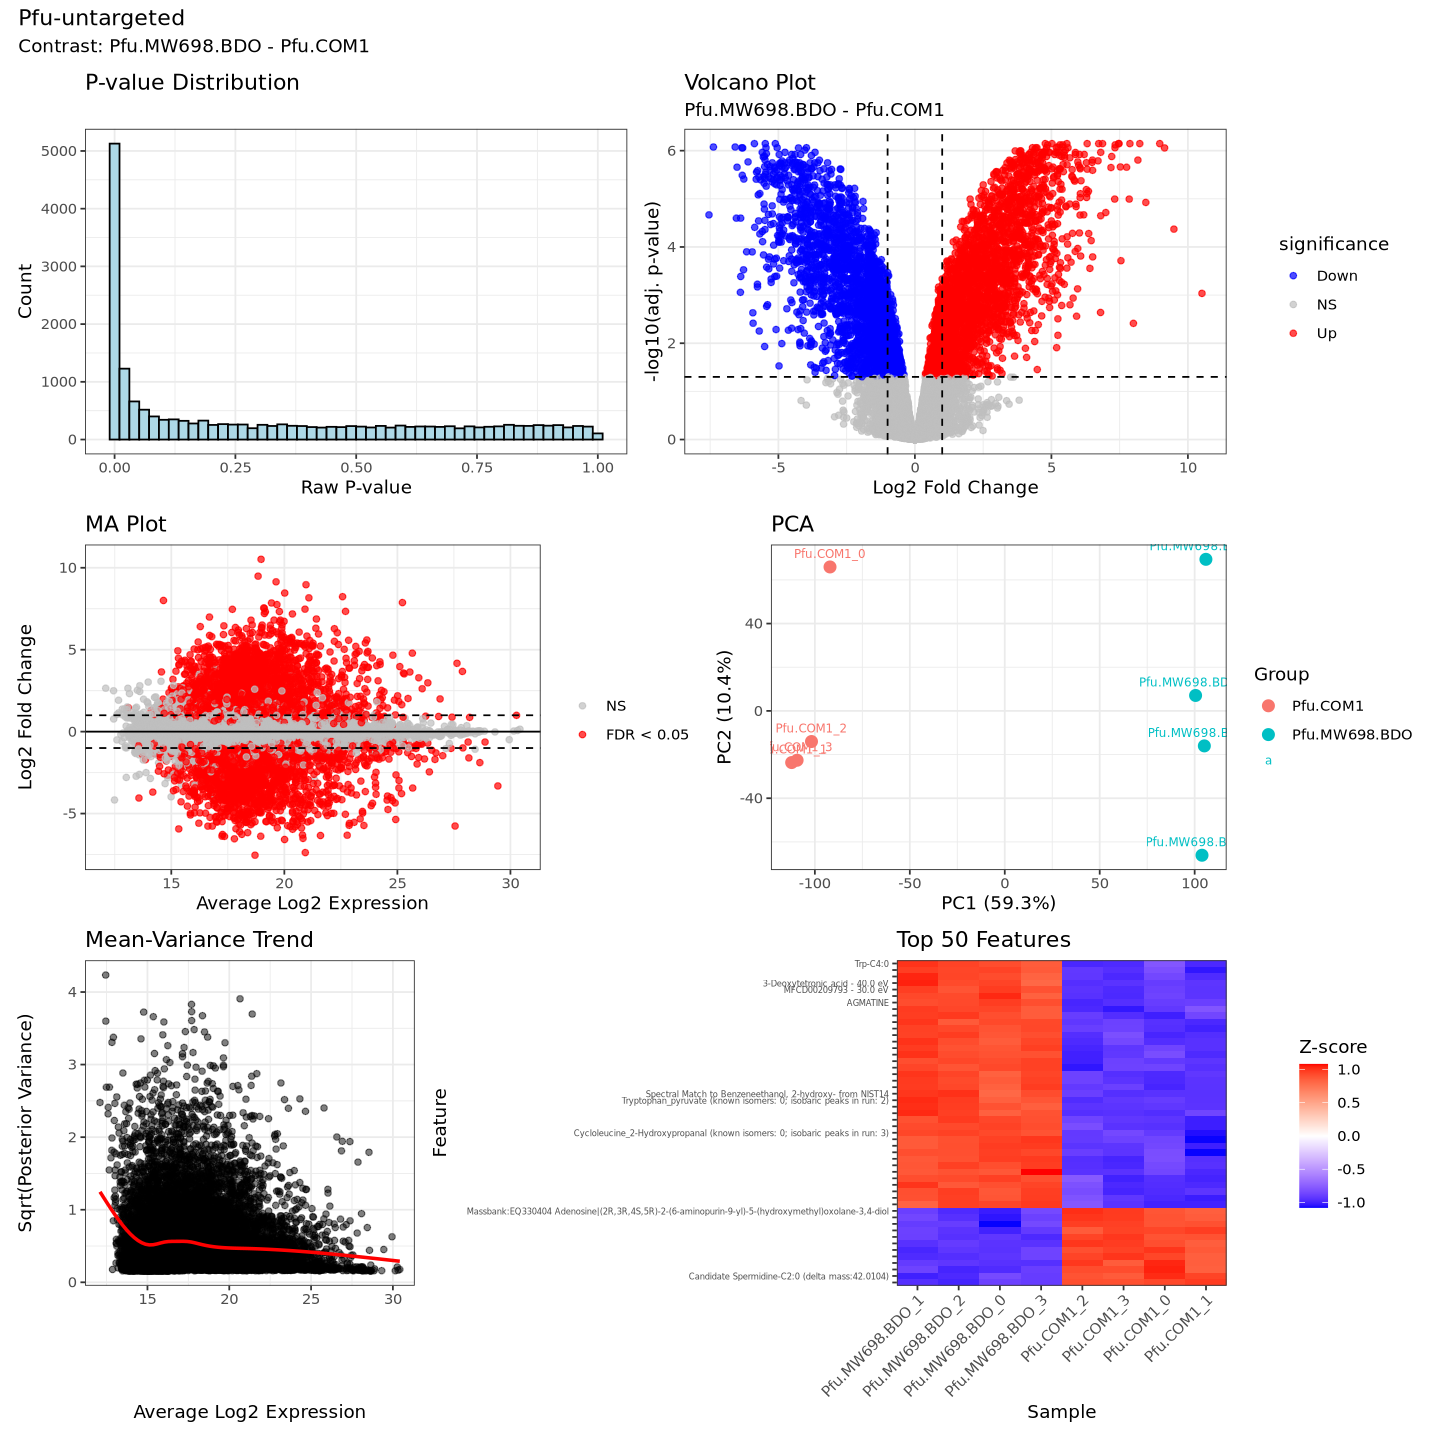

In [18]:
pfu_untargeted_analysis <- run_limma_analysis(pfu_untargeted_imputed,
                                              "Pfu-untargeted",
                                              contrast = "Pfu.MW698.BDO - Pfu.COM1",
                                              group_column = "sample_treatment",
                                              sample_id_column = "sample",
                                              feature_name_col="propagated_annotation")
pfu_untargeted_analysis$plot

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


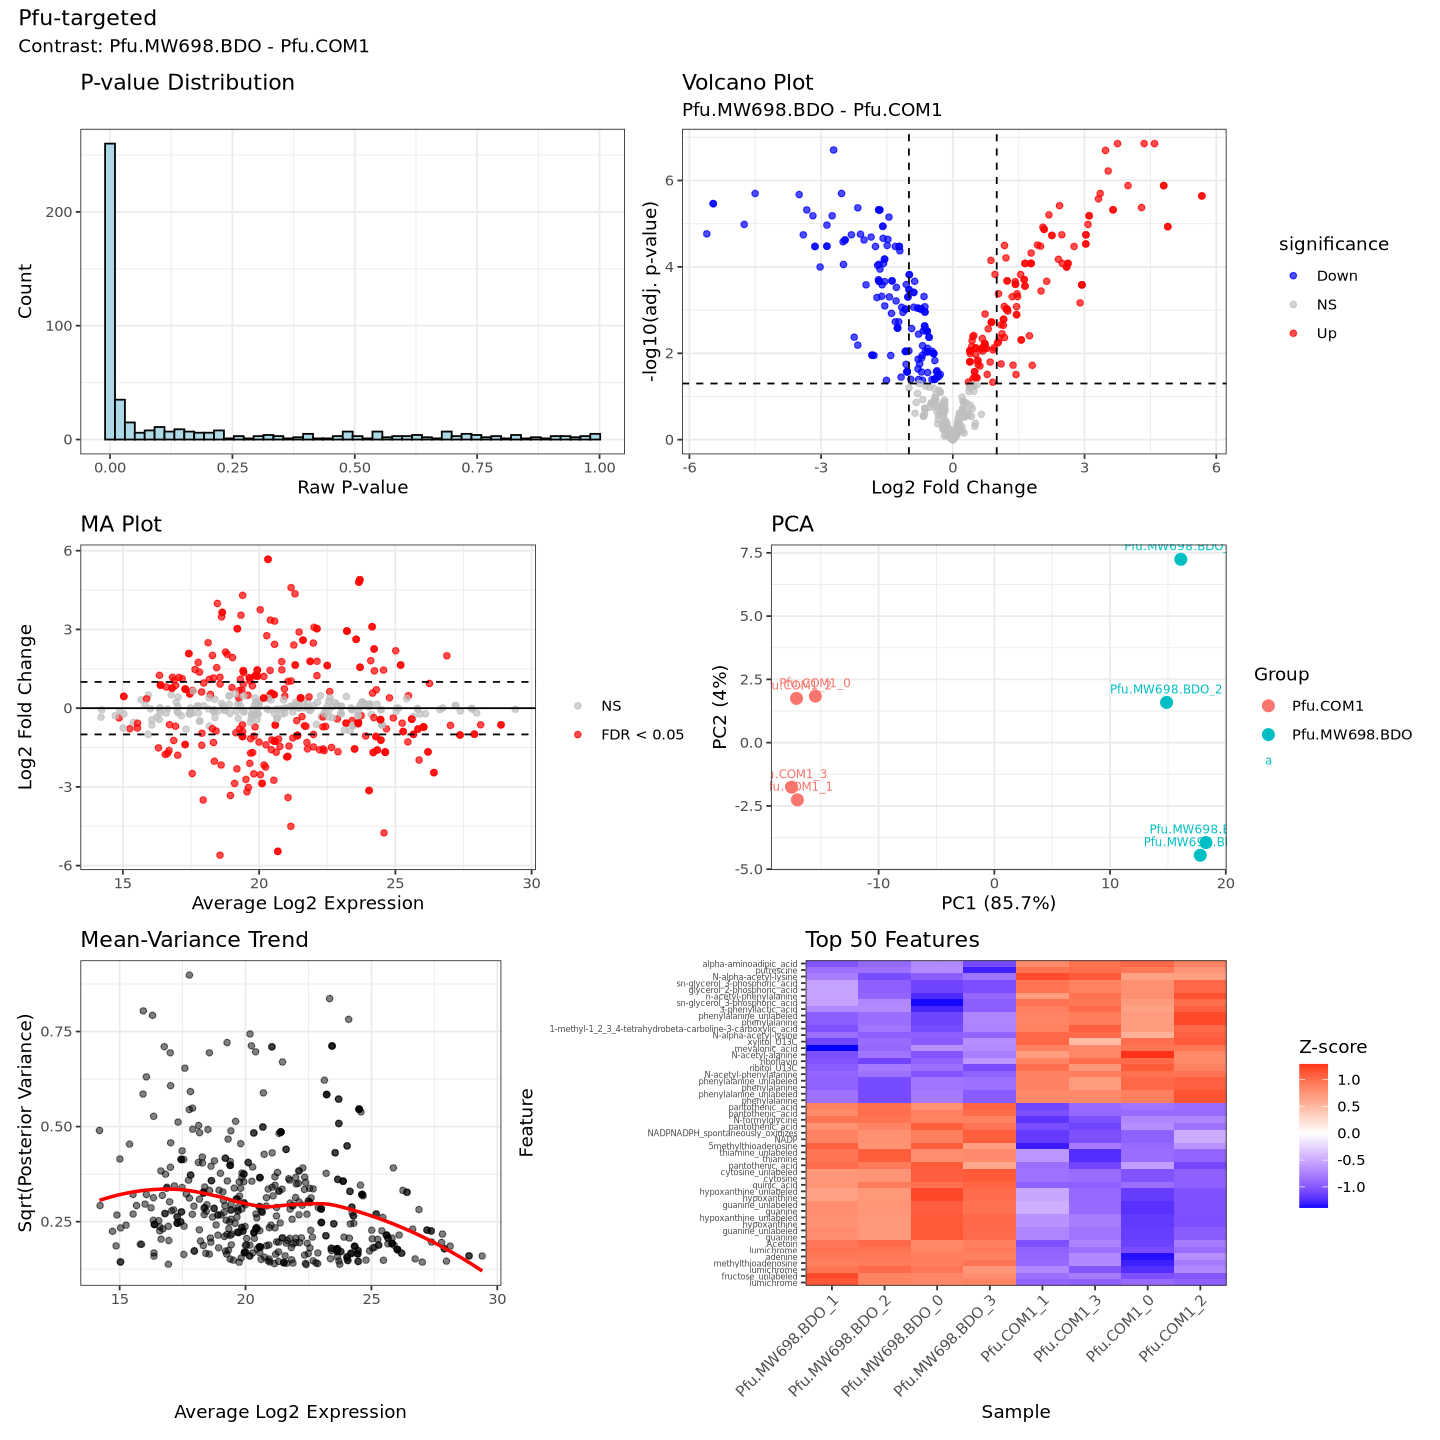

In [19]:
pfu_targeted_analysis <- run_limma_analysis(pfu_targeted_imputed,
                                            "Pfu-targeted",
                                            contrast = "Pfu.MW698.BDO - Pfu.COM1",
                                            group_column = "sample_treatment",
                                            sample_id_column = "sample",
                                            feature_name_col="metabolite")
pfu_targeted_analysis$plot

In [20]:
library(dplyr)


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, setequal, union


The following object is masked from ‘package:generics’:

    explain


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [21]:
pfu_targeted_analysis$results %>% group_by(significance) %>% count()

significance,n
<chr>,<int>
Down,154
NS,194
Up,140


In [22]:
pfu_untargeted_analysis$results %>% group_by(significance) %>% count()

significance,n
<chr>,<int>
Down,2583
NS,13181
Up,2902


In [23]:
write.csv(pfu_targeted_analysis$results, "2026-04-05_Pfu_targeted_limma_results.csv", row.names=TRUE)
write.csv(pfu_untargeted_analysis$results, "2026-04-05_Pfu_untargeted_limma_results.csv", row.names=TRUE)

In [24]:
width_in <- 8
height_in <- 8
dpi <- 300
ggsave("2026-04-05_pfu_targeted_imputation.png", pfu_targeted_imputed$plot, 
       width = width_in, height = height_in, dpi = dpi)
ggsave("2026-04-05_pfu_untargeted_imputation.png", pfu_untargeted_imputed$plot, 
       width = width_in, height = height_in, dpi = dpi)

width_in <- 8
height_in <- 10.5
dpi <- 300

ggsave("2026-04-05_pfu_targeted_analysis.png", pfu_targeted_analysis$plot, 
       width = width_in, height = height_in, dpi = dpi)
ggsave("2026-04-05_pfu_untargeted_analysis.png", pfu_untargeted_analysis$plot, 
       width = width_in, height = height_in, dpi = dpi)

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
